In [1]:
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

# Get MySQL connection details from environment variables
db_host = os.getenv('MYSQL_HOST')
db_port = os.getenv('MYSQL_PORT')
db_name = os.getenv('MARTHOUSE_DATABASE')
db_user = os.getenv('MYSQL_USERNAME')
db_password = os.getenv('MYSQL_PASSWORD')

engine = create_engine(
    f"mysql+mysqlconnector://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
)

In [2]:
import pandas as pd

def load_table(query):
    return pd.read_sql(query, engine)

top_cities = load_table("SELECT * FROM mart_top_polluted_cities")
stations = load_table("SELECT * FROM mart_city_station_details")

In [5]:
city_geo = stations.groupby("city_name").agg({
    "latitude": "mean",
    "longitude": "mean"
}).reset_index()

top_cities_geo = top_cities.merge(city_geo, on="city_name")

In [6]:
import plotly.express as px

fig = px.scatter_map(
    top_cities_geo,
    lat="latitude",
    lon="longitude",
    color="pollutant_type",
    size="avg_pollution",
    hover_name="city_name",
    zoom=7,
    title="Top 10 Polluted Cities in Flanders"
)

fig.show()

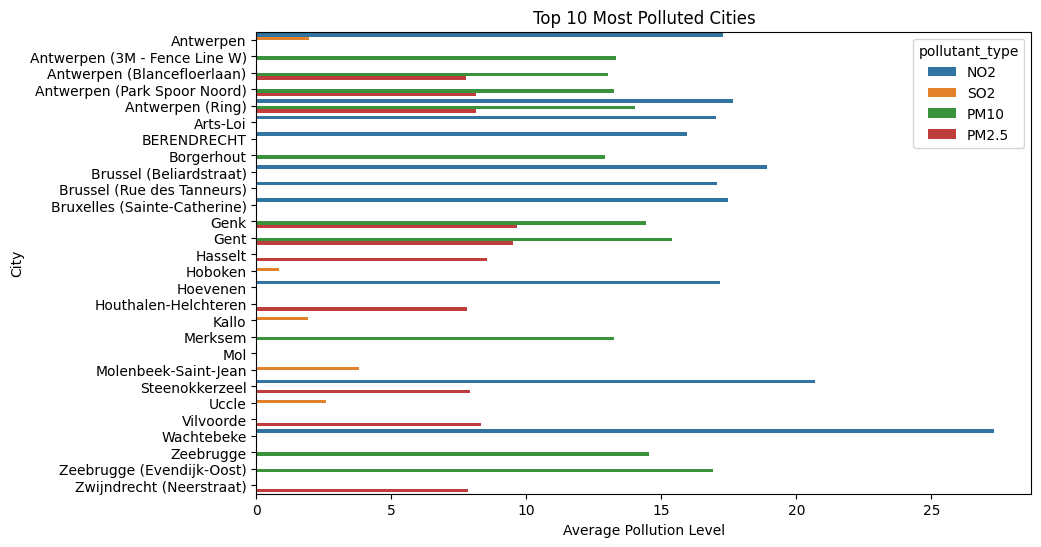

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_cities,
    x="avg_pollution",
    y="city_name",
    hue="pollutant_type"
)

plt.title("Top 10 Most Polluted Cities")
plt.xlabel("Average Pollution Level")
plt.ylabel("City")

plt.show()

<Axes: xlabel='avg_pollution', ylabel='city_name'>

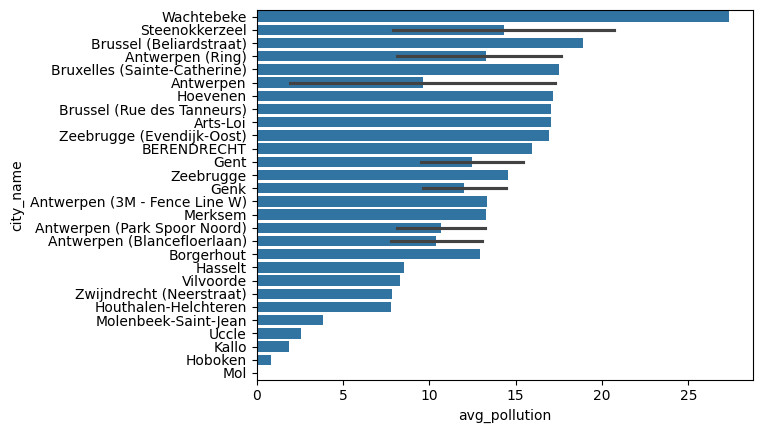

In [6]:
top_sorted = top_cities.sort_values("avg_pollution", ascending=False)

sns.barplot(
    data=top_sorted,
    x="avg_pollution",
    y="city_name"
)

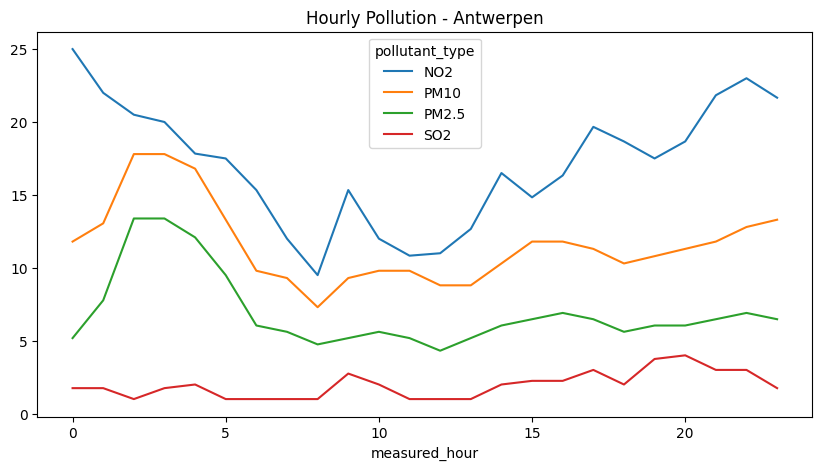

In [8]:
hourly = load_table("SELECT * FROM mart_city_hourly_pollution_vl")

city = "Antwerpen"

df_city = hourly[hourly["city_name"] == city]

pivot = df_city.pivot_table(
    index="measured_hour",
    columns="pollutant_type",
    values="avg_hourly_pollution"
)

pivot.plot(figsize=(10,5))
plt.title(f"Hourly Pollution - {city}")
plt.show()

In [9]:
fig = px.scatter_mapbox(
    stations,
    lat="latitude",
    lon="longitude",
    hover_name="station_name",
    zoom=7,
    title="Monitoring Stations Distribution"
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_38488\2660834834.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [15]:
stations_summary = load_table("SELECT * FROM mart_city_station_coverage")

merged = top_cities.merge(stations_summary, on="city_name")

import plotly.express as px

fig = px.scatter(
    merged,
    x="nb_stations",
    y="avg_pollution",
    color="pollutant_type",
    hover_name="city_name",
    size="avg_pollution",
    title="Pollution vs Number of Stations (Interactive)"
)

fig.show()

In [16]:
fig = px.scatter(
    merged,
    x="nb_stations",
    y="avg_pollution",
    color="city_name",
    facet_col="pollutant_type",
    hover_name="city_name",
    size="avg_pollution",
    title="Pollution vs Stations (Filtered by Pollutant)"
)

fig.show()